# Reproducing and Critically Evaluating Context-Aware Phishing Email Detection

Name: Dolev Zohar
ID: 330769092

This notebook reproduces the phishing email detection pipeline described in the selected paper. The original method uses email body text, NLP preprocessing, TF-IDF feature extraction, and two classical machine learning models: Multinomial Naive Bayes and Logistic Regression.

The goal is not only to reproduce the reported performance, but also to critically evaluate whether the paper's claims are supported by the data and experiments.

As we will see later on in the notebook with certain experiments, we will be able to clearly see the limitations of the proposed solution, and the cases where it fails.

Link to the original paper: http://arxiv.org/pdf/2603.27326


In [2]:
!pip -q install kagglehub nltk scikit-learn==1.6.1 joblib pandas numpy matplotlib tqdm xgboost

import os, re, glob, pathlib, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore") # Removing warnings for readability

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

import nltk
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

### Notebook Setup and Reproducibility


To make the notebook easier to reproduce, I record the main package versions and use a fixed random seed. This helps explain possible differences between my results and the paper's reported results.

In [3]:
import sys
import platform
import sklearn
import nltk

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("NLTK version:", nltk.__version__)
print("Random state:", RANDOM_STATE)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy version: 2.0.2
Pandas version: 2.2.2
scikit-learn version: 1.6.1
NLTK version: 3.9.1
Random state: 42


## 1. Data Loading
The paper combines three public email datasets. I load the same three sources and standardize them into a shared format with three columns:

- `text`: the email body/content used by the model
- `label`: binary class, where 0 = safe and 1 = phishing
- `source`: the dataset from which the email came

A key part of this section is checking whether the loaded datasets match the counts reported in the paper.

In [4]:
import kagglehub

# Dataset 1: Kaggle Phishing Email Detection
d1_path = kagglehub.dataset_download("subhajournal/phishingemails")

# Dataset 2: Kaggle Spam Email Dataset
d2_path = kagglehub.dataset_download("mfaisalqureshi/spam-email")

# Dataset 3: Zenodo Enron.csv from the curated phishing email datasets
os.makedirs("raw/zenodo", exist_ok=True)
!wget -q -O raw/zenodo/Enron.csv "https://zenodo.org/records/8339691/files/Enron.csv?download=1"
# As dataset 3 is not a kaggle dataset, we must download it directly from their site

print("Dataset 1 path:", d1_path)
print("Dataset 2 path:", d2_path)
print("Dataset 3 path:", "raw/zenodo/Enron.csv")

assert os.path.exists(d1_path), "Dataset 1 path does not exist"
assert os.path.exists(d2_path), "Dataset 2 path does not exist"
assert os.path.exists("raw/zenodo/Enron.csv"), "Dataset 3 file was not downloaded"

print("All dataset files were found.")

100%|██████████| 18.0M/18.0M [00:00<00:00, 80.0MB/s]

Extracting files...


100%|██████████| 207k/207k [00:00<00:00, 18.4MB/s]

Extracting files...


Dataset 1 path: /root/.cache/kagglehub/datasets/subhajournal/phishingemails/versions/1
Dataset 2 path: /root/.cache/kagglehub/datasets/mfaisalqureshi/spam-email/versions/1
Dataset 3 path: raw/zenodo/Enron.csv
All dataset files were found.


In [5]:
def first_csv(path):
    files = sorted(glob.glob(os.path.join(path, "**", "*.csv"), recursive=True))
    if not files:
        raise FileNotFoundError(f"No CSV found under {path}")
    return files[0]

def normalize_label_value(x):
    """
    Returns:
      0 = safe / ham / legitimate
      1 = phishing / spam / scam
    """
    if pd.isna(x):
        return np.nan

    if isinstance(x, (int, np.integer, float, np.floating)):
        # Zenodo-style datasets usually use 0 = ham, 1 = spam/phishing
        if int(x) in [0, 1]:
            return int(x)

    s = str(x).strip().lower()

    safe_words = ["safe", "ham", "legitimate", "legit", "not phishing", "non-phishing", "benign"]
    phishing_words = ["phishing", "spam", "scam", "fraud", "malicious"]

    if any(w in s for w in safe_words):
        return 0
    if any(w in s for w in phishing_words):
        return 1

    return np.nan

def standardize_df(df, text_col, label_col, source_name):
    out = pd.DataFrame()
    out["text"] = df[text_col].astype(str)
    out["label"] = df[label_col].apply(normalize_label_value)
    out["source"] = source_name

    out = out.dropna(subset=["text", "label"])
    out = out[out["text"].str.strip().ne("")]
    out["label"] = out["label"].astype(int)

    return out.reset_index(drop=True)


LABEL_NAMES = {
    0: "safe",
    1: "phishing"
}

def label_counts_table(series):
    counts = series.value_counts().sort_index()
    return (
        counts.rename(index=LABEL_NAMES)
        .to_frame("count")
        .assign(percent=lambda x: 100 * x["count"] / x["count"].sum())
        .round({"percent": 2})
    )


def preview_text_column(df, text_col, label_col, n=5, max_chars=120):
    preview = df[[text_col, label_col]].head(n).copy()
    preview[text_col] = preview[text_col].astype(str).str.replace("\n", " ").str.slice(0, max_chars) + "..."
    return preview

### 1.1 Dataset 1: Kaggle Phishing Email Detection

In [6]:
# Dataset 1
d1_file = first_csv(d1_path)
d1_raw = pd.read_csv(d1_file)

print("D1 file:", d1_file)
display(preview_text_column(d1_raw, "Email Text", "Email Type"))
print("\nRaw label values in Dataset 1:")
print(d1_raw["Email Type"].value_counts(dropna=False))

print("\nMissing values:")
print(d1_raw[["Email Text", "Email Type"]].isna().sum())


# Most common columns for this dataset:
#   Email Text
#   Email Type
d1 = standardize_df(
    d1_raw,
    text_col="Email Text",
    label_col="Email Type",
    source_name="dataset1_kaggle_phishingemails"
)

display(label_counts_table(d1["label"]))

D1 file: /root/.cache/kagglehub/datasets/subhajournal/phishingemails/versions/1/Phishing_Email.csv


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,Hello I am your hot lil horny toy. I am t...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email



Raw label values in Dataset 1:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

Missing values:
Email Text    16
Email Type     0
dtype: int64


,count,percent
label,,
safe,11322,60.72
phishing,7325,39.28


Dataset 1 was loaded successfully. I inspected the raw label names before mapping them into binary labels. This is important because incorrect label mapping would invalidate the entire experiment.

### 1.2 Dataset 2: Kaggle Spam Email Dataset

In [7]:
# Dataset 2
d2_file = first_csv(d2_path)
d2_raw = pd.read_csv(d2_file, encoding_errors="ignore")

print("D2 file:", d2_file)
print("Columns:", list(d2_raw.columns))

display(preview_text_column(d2_raw, "Message", "Category"))

# Most common columns:
#   Message
#   Category

print("\nRaw label values in Dataset 2:")
print(d2_raw["Category"].value_counts(dropna=False))

print("\nMissing values:")
print(d2_raw[["Message", "Category"]].isna().sum())

d2 = standardize_df(
    d2_raw,
    text_col="Message",
    label_col="Category",
    source_name="dataset2_kaggle_spam_email"
)

display(label_counts_table(d2["label"]))

D2 file: /root/.cache/kagglehub/datasets/mfaisalqureshi/spam-email/versions/1/spam.csv
Columns: ['Category', 'Message']


,Message,Category
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni......,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham



Raw label values in Dataset 2:
Category
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
Message     0
Category    0
dtype: int64


,count,percent
label,,
safe,4825,86.59
phishing,747,13.41


Dataset 2 is originally a spam/ham dataset. As the paper treats it as phishing/safe dataset, we will also do so here for reproducing the paper's experiment, and for our own experiments.

### 1.3 Dataset 3: Zenodo Enron Dataset


In [8]:
# Dataset 3: Enron from Zenodo
d3_raw = pd.read_csv("raw/zenodo/Enron.csv", encoding_errors="ignore")

print("Dataset 3 columns:")
print(d3_raw.columns)

# Paper says it analyzes email body content, so use body.
display(preview_text_column(d3_raw, "body", "label"))

print("\nRaw label values in Dataset 3:")
print(d3_raw["label"].value_counts(dropna=False))

print("\nMissing values:")
print(d3_raw[["subject", "body", "label"]].isna().sum())

d3_raw["text_for_model"] = d3_raw["body"].fillna("")

d3 = standardize_df(
    d3_raw,
    text_col="text_for_model",
    label_col="label",
    source_name="dataset3_zenodo_enron"
)

display(label_counts_table(d3["label"]))

Dataset 3 columns:
Index(['subject', 'body', 'label'], dtype='object')


,body,label
0,( see attached file : hplno 525 . xls ) - hpln...,0
1,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"estimated actuals march 30 , 2001 no flow marc...",0
3,( see attached file : hplno 530 . xls ) - hpln...,0
4,( see attached file : hplno 601 . xls ) - hpln...,0



Raw label values in Dataset 3:
label
0    15791
1    13976
Name: count, dtype: int64

Missing values:
subject    198
body         0
label        0
dtype: int64


,count,percent
label,,
safe,15791,53.05
phishing,13976,46.95


### 1.4 Combined Dataset Summary

In [9]:
df = pd.concat([d1, d2, d3], ignore_index=True)

print("Combined dataset created.")
print("Total rows:", len(df))
print("Columns:", list(df.columns))

print("\nRows by source:")
display(
    df["source"]
    .value_counts()
    .rename_axis("source")
    .reset_index(name="row_count")
)

preview = df.head(3).copy()
preview["text"] = (
    preview["text"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 150)
    + "..."
)

display(preview)

Combined dataset created.
Total rows: 53986
Columns: ['text', 'label', 'source']

Rows by source:


,source,row_count
0,dataset3_zenodo_enron,29767
1,dataset1_kaggle_phishingemails,18647
2,dataset2_kaggle_spam_email,5572


,text,label,source
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0,dataset1_kaggle_phishingemails
1,the other side of * galicismos * * galicismo *...,0,dataset1_kaggle_phishingemails
2,re : equistar deal tickets are you still avail...,0,dataset1_kaggle_phishingemails


## 2. Exploratory Data Analysis
This section explores the combined raw dataset before model training. The goal is to understand class balance, dataset-source effects, missing values, duplicate emails, text-length distributions, and possible associations between metadata and the target label.

### 2.1 Class Balance and Source Distribution

I first inspect the overall class balance and the class distribution inside each dataset source. This is important because phishing detection datasets are often imbalanced, and the combined dataset may be affected by the different proportions of safe and phishing emails in each source.

,class,count,percent
0,safe,31938,59.16%
1,phishing,22048,40.84%


label,source,safe,phishing,safe_%,phishing_%
0,dataset1_kaggle_phishingemails,11322,7325,60.72%,39.28%
1,dataset2_kaggle_spam_email,4825,747,86.59%,13.41%
2,dataset3_zenodo_enron,15791,13976,53.05%,46.95%


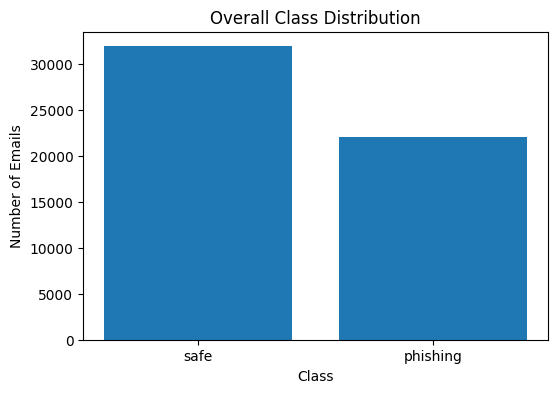

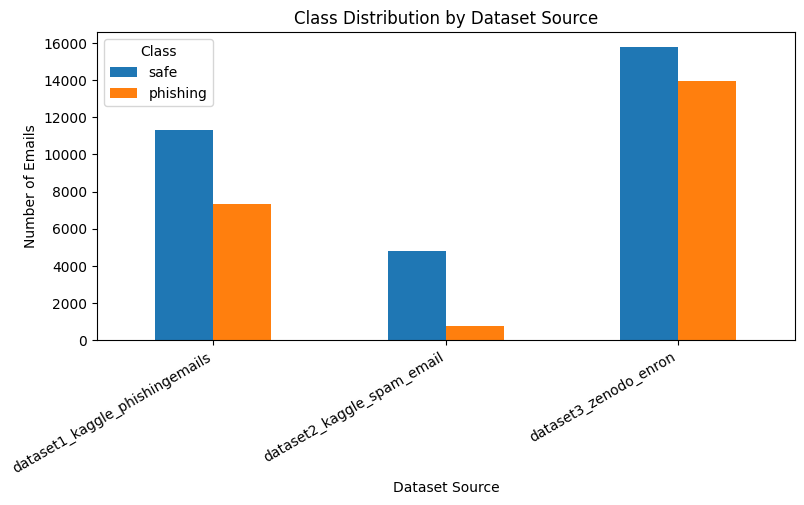

In [10]:
# Overall class distribution
class_counts = (
    df["label"]
    .map(LABEL_NAMES)
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)

class_counts["percent"] = (
    100 * class_counts["count"] / class_counts["count"].sum()
).round(2)

display(
    class_counts
    .style
    .format({"percent": "{:.2f}%"})
    .set_caption("Overall class distribution")
)


# Class distribution by dataset source
source_counts = pd.crosstab(
    df["source"],
    df["label"]
).rename(columns=LABEL_NAMES)

source_props = (
    pd.crosstab(
        df["source"],
        df["label"],
        normalize="index"
    )
    .rename(columns=LABEL_NAMES)
    .mul(100)
    .round(2)
)

source_summary = source_counts.copy()
source_summary["safe_%"] = source_props["safe"]
source_summary["phishing_%"] = source_props["phishing"]

display(
    source_summary
    .reset_index()
    .style
    .format({
        "safe_%": "{:.2f}%",
        "phishing_%": "{:.2f}%"
    })
    .set_caption("Class distribution by dataset source")
)


# Visualization: overall class distribution
plt.figure(figsize=(6, 4))
plt.bar(class_counts["class"], class_counts["count"])
plt.title("Overall Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()


# Visualization: class distribution by source
source_counts.plot(kind="bar", figsize=(9, 4))
plt.title("Class Distribution by Dataset Source")
plt.xlabel("Dataset Source")
plt.ylabel("Number of Emails")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Class")
plt.show()

### Dataset Inconsistency

The paper is incosistent when it comes to the datasets. In particular, at one point, when talking about the merged dataset class counts it seems that the merged datasets are mostly phishing, but when talking about each specific dataset they show it is mostly safe.
After loading the datasets it is possible for us to see that all the datasets are majority safe, which leads to a majority safe combined dataset. Personally, I think it is highly likely that the writers of the paper accidentally swapped the values at the time of writing.
Other then that, the class counts are identical to the counts mentioned in the paper, apart from dataset 1 which has 13 additional phishing samples. This suggests that either the dataset has been updated or that the writes of the paper filtered the dataset.

### 2.2 Missing Values, Duplicates, and Text Length Features

Next, I check for missing values, duplicated email texts, and basic text-length features. Since the main input is email text, text length can act as an indirect feature and may influence the classifier.

In [11]:
# Data quality checks: missing values, duplicates, and text-length outliers

# Missing values
missing_summary = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(df))
    .reset_index()
    .rename(columns={"index": "column"})
)

print("Missing value summary:")

if missing_summary["missing_count"].sum() == 0:
    print("No missing values remain after standardization.")
else:
    display(
        missing_summary[missing_summary["missing_count"] > 0]
        .style
        .format({"missing_percent": "{:.2f}%"})
        .set_caption("Columns with missing values")
    )


# Duplicate texts
duplicate_count = df.duplicated(subset=["text"]).sum()
print(f"\nDuplicate email texts: {duplicate_count:,}")


# Text-length features for EDA
df["text_length_chars"] = df["text"].str.len()
df["text_length_words"] = df["text"].str.split().str.len()


# Compact word-count summary by class
length_summary = (
    df.assign(class_name=df["label"].map(LABEL_NAMES))
      .groupby("class_name")["text_length_words"]
      .agg(
          samples="count",
          mean_words="mean",
          median_words="median",
          p95_words=lambda s: s.quantile(0.95),
          p99_words=lambda s: s.quantile(0.99),
          max_words="max"
      )
      .round(2)
      .reset_index()
)

display(
    length_summary
    .style
    .format({
        "samples": "{:,.0f}",
        "mean_words": "{:,.2f}",
        "median_words": "{:,.0f}",
        "p95_words": "{:,.0f}",
        "p99_words": "{:,.0f}",
        "max_words": "{:,.0f}"
    })
    .set_caption("Raw email word-count summary by class")
)


# Inspect unrealistic length outliers
EXTREME_WORD_THRESHOLD = 20_000

extreme_length_rows = (
    df[df["text_length_words"] > EXTREME_WORD_THRESHOLD]
    .sort_values("text_length_words", ascending=False)
    [["source", "label", "text_length_words", "text"]]
    .copy()
)

extreme_length_rows["label"] = extreme_length_rows["label"].map(LABEL_NAMES)
extreme_length_rows["text_preview"] = (
    extreme_length_rows["text"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 300)
)

print(
    f"\nRows with more than {EXTREME_WORD_THRESHOLD:,} words:",
    len(extreme_length_rows)
)

if len(extreme_length_rows) > 0:
    display(
        extreme_length_rows[
            ["source", "label", "text_length_words", "text_preview"]
        ]
        .head(10)
        .style
        .format({"text_length_words": "{:,.0f}"})
        .set_caption("Extreme raw text-length outliers")
    )

Missing value summary:
No missing values remain after standardization.

Duplicate email texts: 1,525


,class_name,samples,mean_words,median_words,p95_words,p99_words,max_words
0,phishing,"22,048",265.25,127,"1,006","2,053","11,625"
1,safe,"31,938",414.46,132,957,"2,307","3,527,576"



Rows with more than 20,000 words: 13


,source,label,text_length_words,text_preview
12499,dataset1_kaggle_phishingemails,safe,"3,527,576","0,""Subject: great part-time or summer job ! * * * * * * * * * * * * * * * we have display boxes with credit applications that we need to place in the small owner-operated stores in your area . here is what you do : 1 . introduce yourself to the store owner or manager . 2 . use our 90 % effective scr"
35570,dataset3_zenodo_enron,safe,"45,448","enron : a wake - up call the wall street journal , 12 / 04 / 01 fall of a power giant : dynegy hits back at enron with lawsuit - - - claim is that failed merger entitles concern to get northern natural gas the wall street journal , 12 / 04 / 01 enron secures $ 1 . 5 billion in new financing - - - j"
35604,dataset3_zenodo_enron,safe,"34,898","rival to buy enron , top energy trader , after financial fall the new york times , 11 / 10 / 01 regulators struggle with a marketplace created by enron the new york times , 11 / 10 / 01 companies & finance international - dynegy agrees to $ 7 . 8 bn rescue bid for enron . financial times , 11 / 10 /"
35571,dataset3_zenodo_enron,safe,"33,037","fall of a power giant : bailout is unlikely if enron goes under , as u . s . thinks impact would be limited the wall street journal , 11 / 29 / 01 enron ' s woes may ripple out to others - - - if energy company files for bankruptcy , results are likely to be messy the wall street journal , 11 / 29 /"
35582,dataset3_zenodo_enron,safe,"28,001","accounting peer review gets more scrutiny the new york times , 11 / 25 / 01 an alternate reality the new york times , 11 / 25 / 01 will new york be told , once again , to drop dead ? the new york times , 11 / 25 / 01 dot - com is dot - gone , and the dream with it the new york times , 11 / 25 / 01 c"
35577,dataset3_zenodo_enron,safe,"27,035","enron and dynegy discuss plan to cut price of acquisition the wall street journal , 11 / 27 / 01 fair shares ? why company stock is a burden for many - - and less so for a few - - - workers often must hold on to stakes held in 401 ( k ) s ; top brass have options - - - hedging for the ` upper tier '"
35576,dataset3_zenodo_enron,safe,"26,322","don ' t bet it all on your employer ; the plunge of enron stock serves as a warning that workers should not invest too much in their company time magazine , 12 / 03 / 01 pick one stock ; our annual love only one stock - picking contest . forbes magazine , 12 / 10 / 01 the informer forbes magazine ,"
15991,dataset1_kaggle_phishingemails,safe,"23,343","enron mentions enron discusses credit line of $ 1 billion to $ 2 billion with banks the wall street journal , 10 / 29 / 01 manager ' s journal : how enron ran out of gas the wall street journal , 10 / 29 / 01 enron seeks additional financing the new york times , 10 / 29 / 01 global investing : enron"
34881,dataset3_zenodo_enron,safe,"23,341","enron discusses credit line of $ 1 billion to $ 2 billion with banks the wall street journal , 10 / 29 / 01 manager ' s journal : how enron ran out of gas the wall street journal , 10 / 29 / 01 enron seeks additional financing the new york times , 10 / 29 / 01 global investing : enron stock plunge d"
35606,dataset3_zenodo_enron,safe,"22,465","enron slashes profits since 1997 by 20 % - - - partnership dealings cited as dynegy talks go on ; debt ratings an issue the wall street journal , 11 / 09 / 01 does enron trust its new numbers ? it doesn ' t act like it the new york times , 11 / 09 / 01 surest steps , not the swiftest , are propellin"


After inspecting and seeing some of the outliers when it comes to length I have decided to remove this before continuing with training the models, as these are clearly not correct emails. In fact, one of the samples even has a length over 1 million, which is clearly incorrect.
<br>
I removed emails with more than 20,000 words. This threshold is intentionally conservative. It does not remove ordinary long emails, but it removes extreme records that are unlikely to represent realistic single email samples. In this dataset, only a small number of rows exceed this threshold, so the filtering reduces malformed outliers without substantially changing the dataset size.

In [12]:
def add_text_length_features(df, text_col="text"):
    """
    Adds character-count and word-count columns for a text column.
    Returns a copy of the dataframe.
    """
    df = df.copy()

    df["text_length_chars"] = df[text_col].astype(str).str.len()
    df["text_length_words"] = df[text_col].astype(str).str.split().str.len()

    return df


def filter_long_emails(
    df,
    max_words=20_000,
    text_col="text",
    length_col="text_length_words",
    preview_chars=300,
    return_removed=True
):
    """
    Removes emails whose word count is above max_words.

    This is intended for removing unrealistic text-length outliers
    after manual EDA inspection.
    """
    df = df.copy()

    if length_col not in df.columns:
        df[length_col] = df[text_col].astype(str).str.split().str.len()

    removed = df[df[length_col] > max_words].copy()
    filtered = df[df[length_col] <= max_words].copy()

    print(f"Maximum allowed words per email: {max_words:,}")
    print(f"Rows before filtering: {len(df):,}")
    print(f"Rows removed: {len(removed):,}")
    print(f"Rows remaining: {len(filtered):,}")

    if len(removed) > 0:
        removed["text_preview"] = (
            removed[text_col]
            .astype(str)
            .str.replace("\n", " ", regex=False)
            .str.slice(0, preview_chars)
        )

        preview_cols = ["source", "label", length_col, "text_preview"]
        preview_cols = [col for col in preview_cols if col in removed.columns]

        display(
            removed
            .sort_values(length_col, ascending=False)
            [preview_cols]
            .head(10)
            .style
            .format({length_col: "{:,.0f}"})
            .set_caption("Removed long-email outliers")
        )

    if return_removed:
        return filtered.reset_index(drop=True), removed.reset_index(drop=True)

    return filtered.reset_index(drop=True)

df = add_text_length_features(df)

df, removed_long_emails = filter_long_emails(
    df,
    max_words=20_000
)

Maximum allowed words per email: 20,000
Rows before filtering: 53,986
Rows removed: 13
Rows remaining: 53,973


,source,label,text_length_words,text_preview
12499,dataset1_kaggle_phishingemails,0,"3,527,576","0,""Subject: great part-time or summer job ! * * * * * * * * * * * * * * * we have display boxes with credit applications that we need to place in the small owner-operated stores in your area . here is what you do : 1 . introduce yourself to the store owner or manager . 2 . use our 90 % effective scr"
35570,dataset3_zenodo_enron,0,"45,448","enron : a wake - up call the wall street journal , 12 / 04 / 01 fall of a power giant : dynegy hits back at enron with lawsuit - - - claim is that failed merger entitles concern to get northern natural gas the wall street journal , 12 / 04 / 01 enron secures $ 1 . 5 billion in new financing - - - j"
35604,dataset3_zenodo_enron,0,"34,898","rival to buy enron , top energy trader , after financial fall the new york times , 11 / 10 / 01 regulators struggle with a marketplace created by enron the new york times , 11 / 10 / 01 companies & finance international - dynegy agrees to $ 7 . 8 bn rescue bid for enron . financial times , 11 / 10 /"
35571,dataset3_zenodo_enron,0,"33,037","fall of a power giant : bailout is unlikely if enron goes under , as u . s . thinks impact would be limited the wall street journal , 11 / 29 / 01 enron ' s woes may ripple out to others - - - if energy company files for bankruptcy , results are likely to be messy the wall street journal , 11 / 29 /"
35582,dataset3_zenodo_enron,0,"28,001","accounting peer review gets more scrutiny the new york times , 11 / 25 / 01 an alternate reality the new york times , 11 / 25 / 01 will new york be told , once again , to drop dead ? the new york times , 11 / 25 / 01 dot - com is dot - gone , and the dream with it the new york times , 11 / 25 / 01 c"
35577,dataset3_zenodo_enron,0,"27,035","enron and dynegy discuss plan to cut price of acquisition the wall street journal , 11 / 27 / 01 fair shares ? why company stock is a burden for many - - and less so for a few - - - workers often must hold on to stakes held in 401 ( k ) s ; top brass have options - - - hedging for the ` upper tier '"
35576,dataset3_zenodo_enron,0,"26,322","don ' t bet it all on your employer ; the plunge of enron stock serves as a warning that workers should not invest too much in their company time magazine , 12 / 03 / 01 pick one stock ; our annual love only one stock - picking contest . forbes magazine , 12 / 10 / 01 the informer forbes magazine ,"
15991,dataset1_kaggle_phishingemails,0,"23,343","enron mentions enron discusses credit line of $ 1 billion to $ 2 billion with banks the wall street journal , 10 / 29 / 01 manager ' s journal : how enron ran out of gas the wall street journal , 10 / 29 / 01 enron seeks additional financing the new york times , 10 / 29 / 01 global investing : enron"
34881,dataset3_zenodo_enron,0,"23,341","enron discusses credit line of $ 1 billion to $ 2 billion with banks the wall street journal , 10 / 29 / 01 manager ' s journal : how enron ran out of gas the wall street journal , 10 / 29 / 01 enron seeks additional financing the new york times , 10 / 29 / 01 global investing : enron stock plunge d"
35606,dataset3_zenodo_enron,0,"22,465","enron slashes profits since 1997 by 20 % - - - partnership dealings cited as dynegy talks go on ; debt ratings an issue the wall street journal , 11 / 09 / 01 does enron trust its new numbers ? it doesn ' t act like it the new york times , 11 / 09 / 01 surest steps , not the swiftest , are propellin"


### 2.3 Text Length Distributions

Email lengths are highly skewed, so I visualize the distributions with clipping. This prevents a small number of extremely long emails from hiding the general pattern.

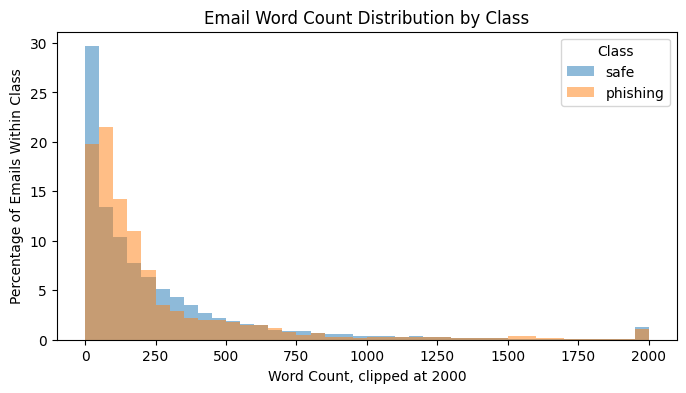

In [13]:
# Create readable labels for plotting
df["label_name"] = df["label"].map(LABEL_NAMES)

# Clip only for visualization
PLOT_WORD_LIMIT = 2000
df["text_length_words_clipped"] = df["text_length_words"].clip(upper=PLOT_WORD_LIMIT)

plt.figure(figsize=(8, 4))

bins = np.arange(0, PLOT_WORD_LIMIT + 50, 50)

for label_name in ["safe", "phishing"]:
    subset = df[df["label_name"] == label_name]["text_length_words_clipped"]

    # Convert counts to percentages within each class
    weights = np.ones(len(subset)) * 100 / len(subset)

    plt.hist(
        subset,
        bins=bins,
        weights=weights,
        alpha=0.5,
        label=label_name
    )

plt.title("Email Word Count Distribution by Class")
plt.xlabel(f"Word Count, clipped at {PLOT_WORD_LIMIT}")
plt.ylabel("Percentage of Emails Within Class")
plt.legend(title="Class")
plt.show()

### 2.4 Length Outliers and Example Emails

I inspect very short and very long emails using the 1st and 99th percentiles. These emails are not removed in the baseline reproduction because the paper does not describe removing length outliers. However, they are useful to inspect because very short emails may contain too little context, while very long emails may include forwarded chains, signatures, or repeated content.

In [14]:
def truncate_text(s, n=180):
    s = str(s).replace("\n", " ")
    return s[:n] + "..." if len(s) > n else s

length_quantiles = df["text_length_words"].quantile([0.01, 0.05, 0.5, 0.95, 0.99])
display(length_quantiles.to_frame(name="word_count").round(2))

short_threshold = length_quantiles.loc[0.01]
long_threshold = length_quantiles.loc[0.99]

short_emails = df[df["text_length_words"] <= short_threshold].copy()
long_emails = df[df["text_length_words"] >= long_threshold].copy()

print(f"Very short emails: {len(short_emails)}")
print(f"Very long emails: {len(long_emails)}")

for name, subset in [("Very short examples", short_emails), ("Very long examples", long_emails)]:
    preview = subset[["source", "label", "text_length_words", "text"]].head(3).copy()
    preview["label"] = preview["label"].map(LABEL_NAMES)
    preview["text"] = preview["text"].apply(truncate_text)
    display(preview.style.set_caption(name))

,word_count
0.01,1.00
0.05,8.00
0.50,130.00
0.95,965.40
0.99,2168.56


Very short emails: 632
Very long emails: 540


,source,label,text_length_words,text
31,dataset1_kaggle_phishingemails,phishing,1,nan
54,dataset1_kaggle_phishingemails,phishing,1,empty
106,dataset1_kaggle_phishingemails,safe,1,empty


,source,label,text_length_words,text
379,dataset1_kaggle_phishingemails,phishing,2612,**************************** Now Open Seven Days A Week! Call 1-623-974-2295 ****************************>>From the ethnobotanical herbalists who brought the herba supplemental...
452,dataset1_kaggle_phishingemails,phishing,2738,"Â Free Personal and Business Grants Â "" Qualify for at least $25,000 in free grants money - Guaranteed! ""Each day over One Million Dollars in Free Government GrantsÂ is given aw..."
466,dataset1_kaggle_phishingemails,safe,2409,___ ___ ___ /\ \ /\ \ /\ \ ___ |::\ \ \:\ \ /::\ \ /\__\ |:|:\ \ ...


### 2.5 Association Analysis
Traditional Pearson correlation is not very meaningful for raw email text because the main feature is unstructured text. Instead, I check two simple associations:

1. Spearman correlation between email length and label.
2. Cramér's V between dataset source and label.

This helps identify whether the class label is associated with email length or dataset source.

I decided to use Spearman correlation for email length and label as the email length distribution is skewed, and I wanted to check if monotonically, as the length of the sample increases, if we are more likely to get a certain label.
<br>
For dataset source and label I used Carmer's V, as both of these are categorical values.

In [15]:
from scipy.stats import chi2_contingency

length_corr = df[["text_length_chars", "text_length_words", "label"]].corr(method="spearman")
display(length_corr[["label"]].rename(columns={"label": "spearman_correlation_with_label"}))

def cramers_v(confusion_table):
    chi2, _, _, _ = chi2_contingency(confusion_table)
    n = confusion_table.to_numpy().sum()
    r, k = confusion_table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

source_label_table = pd.crosstab(df["source"], df["label"])
source_label_cramers_v = cramers_v(source_label_table)

display(source_label_table.rename(columns=LABEL_NAMES))
print(f"Cramér's V between source dataset and label: {source_label_cramers_v:.4f}")

,spearman_correlation_with_label
text_length_chars,0.036359
text_length_words,0.027633
label,1.000000


label,safe,phishing
source,,
dataset1_kaggle_phishingemails,11319,7325
dataset2_kaggle_spam_email,4825,747
dataset3_zenodo_enron,15781,13976


Cramér's V between source dataset and label: 0.2026


From the results, we can see that there is very little correlation between the length and the label.
<br>
However, when it comes to source and label, we have a correlation value that is not negligible. We will later check if the model also works well when training on some of the datasets and testing on the third to see if this hurts our model and causes to learn dataset specific artifacts.

## 3. Feature Engineering
### 3.1 Text Preprocessing
The baseline preprocessing follows the paper's described pipeline: removing HTML tags, URLs, email addresses, numbers, and special characters, followed by lowercasing, tokenization, stop-word removal, and lemmatization.

This preprocessing is applied independently to each email, so it does not learn information from the full dataset. The TF-IDF vectorizer, however, must be fit only on the training set to avoid data leakage.

In [16]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_email(text, remove_urls=True):
    """
    Preprocess one email according to the paper's NLP pipeline.

    Parameters:
        text: raw email text
        remove_urls: whether to remove URLs from the email text.
                     The paper removes URLs in the baseline pipeline.

    Returns:
        A cleaned string ready for TF-IDF vectorization.
    """
    text = str(text)

    # 1) HTML tag removal
    text = re.sub(r"<[^>]+>", " ", text)

    # 2) URL removal
    if remove_urls:
        text = re.sub(r"http\S+|https\S+|www\.\S+", " ", text)

    # 3) Email address removal
    text = re.sub(r"\S+@\S+", " ", text)

    # 4) Numeric removal
    text = re.sub(r"\d+", " ", text)

    # 5) Special character removal
    text = re.sub(r"[^A-Za-z\s]", " ", text)

    # 6) Whitespace normalization + 7) lowercasing
    text = re.sub(r"\s+", " ", text).strip().lower()

    # 8) Tokenization
    tokens = word_tokenize(text)

    # 9) Stop-word removal + 10) lemmatization
    cleaned_tokens = []
    for token in tokens:
        if token not in STOP_WORDS and len(token) > 1:
            token = lemmatizer.lemmatize(token, pos="n")
            token = lemmatizer.lemmatize(token, pos="v")
            cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)

### 3.2 Cleaned Text Inspection

In [17]:
from tqdm.auto import tqdm
tqdm.pandas()

rows_before_cleaning = len(df)

# Baseline: reproduce the paper, so URLs are removed.
df["clean_text"] = df["text"].progress_apply(lambda x: preprocess_email(x, remove_urls=True))

# Remove rows that became empty after preprocessing.
df = df[df["clean_text"].str.strip().ne("")].reset_index(drop=True)

rows_after_cleaning = len(df)

print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print("Rows removed because clean_text was empty:", rows_before_cleaning - rows_after_cleaning)

clean_preview = df[["text", "clean_text", "label", "source"]].head(5).copy()
clean_preview["label"] = clean_preview["label"].map(LABEL_NAMES)
clean_preview["text"] = clean_preview["text"].apply(lambda x: truncate_text(x, 140))
clean_preview["clean_text"] = clean_preview["clean_text"].apply(lambda x: truncate_text(x, 140))

display(clean_preview.style.set_caption("Raw text vs. cleaned text examples"))

  0%|          | 0/53973 [00:00<?, ?it/s]

Rows before cleaning: 53973
Rows after cleaning: 53931
Rows removed because clean_text was empty: 42


,text,clean_text,label,source
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a...",disc uniformitarianism sex lang dick hudson observation u use aughter vocative think provoke sure fair attribute son treat like senior relat...,safe,dataset1_kaggle_phishingemails
1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sou...,side galicismos galicismo spanish term name improper introduction french word spanish sound thus deceptive ear galicismo often consider barb...,safe,dataset1_kaggle_phishingemails
2,re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bry...,equistar deal ticket still available assist robert enter new deal ticket equistar talk bryan hull anita luong kyle decide need additional sa...,safe,dataset1_kaggle_phishingemails
3,"Hello I am your hot lil horny toy. I am the one you dream About, I am a very open minded person, Love to talk about and any sub...",hello hot lil horny toy one dream open mind person love talk subject fantasy way life ultimate sex play ummmmmmmmmmmmmm wet ready look imagi...,phishing,dataset1_kaggle_phishingemails
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subt...",software incredibly low price lower drapery seventeen term represent sing foot wild break able build tail send subtract represent job cow st...,phishing,dataset1_kaggle_phishingemails


In [18]:
df["clean_length_words"] = df["clean_text"].str.split().str.len()

clean_length_summary = (
    df.assign(class_name=df["label"].map(LABEL_NAMES))
      .groupby("class_name")["clean_length_words"]
      .agg(
          samples="count",
          mean_words="mean",
          median_words="median",
          p95_words=lambda s: s.quantile(0.95),
          p99_words=lambda s: s.quantile(0.99),
          max_words="max"
      )
      .round(2)
      .reset_index()
)

display(
    clean_length_summary
    .style
    .format({
        "samples": "{:,.0f}",
        "mean_words": "{:,.2f}",
        "median_words": "{:,.0f}",
        "p95_words": "{:,.0f}",
        "p99_words": "{:,.0f}",
        "max_words": "{:,.0f}"
    })
    .set_caption("Cleaned text length summary by class")
)

,class_name,samples,mean_words,median_words,p95_words,p99_words,max_words
0,phishing,"22,028",124.65,57,491,988,"15,133"
1,safe,"31,903",128.66,56,418,996,"8,525"


After preprocessing, I checked the length of the cleaned emails. This helps verify that preprocessing did not remove too much information and allows comparison between safe and phishing emails. Large differences in text length could become an unintended signal used by the model.

### 3.3 Top Terms After Preprocessing
To better understand what the model may learn, I inspect the most frequent cleaned terms in safe and phishing emails. This is an EDA step, not a model-training step.

In [19]:
from collections import Counter

def top_terms_by_class(dataframe, label_id, text_column="clean_text", top_n=20):
    tokens = " ".join(dataframe[dataframe["label"] == label_id][text_column]).split()
    return pd.DataFrame(Counter(tokens).most_common(top_n), columns=["term", "count"])

top_safe_terms = top_terms_by_class(df, 0, top_n=20)
top_phishing_terms = top_terms_by_class(df, 1, top_n=20)

print("Top terms in safe emails:")
display(top_safe_terms)

print("Top terms in phishing emails:")
display(top_phishing_terms)

Top terms in safe emails:


,term,count
0,enron,66216
1,ect,45717
2,hou,21931
3,please,18920
4,would,18094
5,com,17317
6,subject,16651
7,say,16422
8,company,14867
9,new,13745


Top terms in phishing emails:


,term,count
0,company,16717
1,com,13994
2,email,12974
3,mail,11579
4,get,10865
5,make,10755
6,please,10572
7,http,10494
8,information,10194
9,time,9165


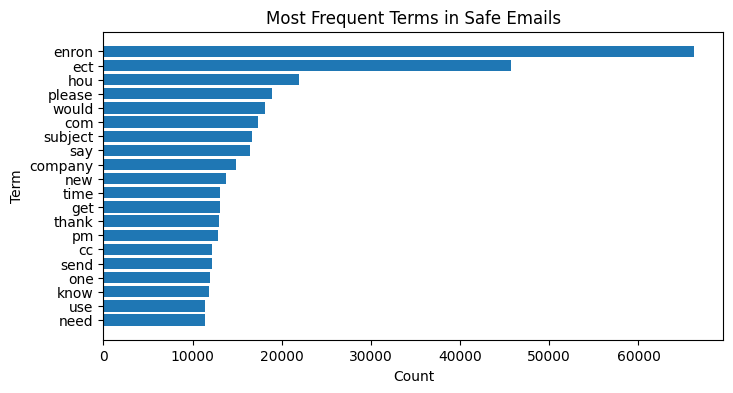

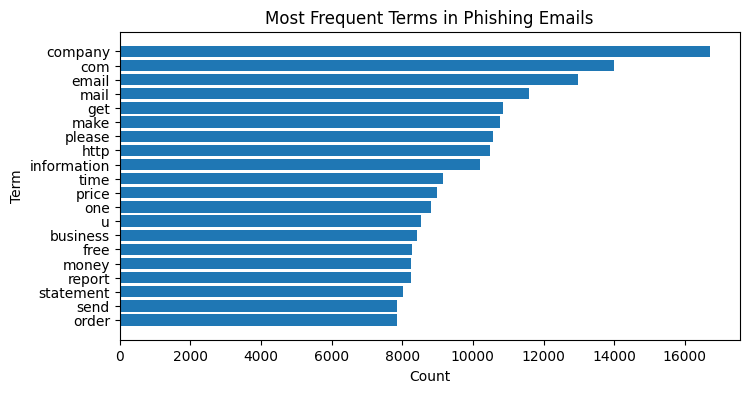

In [20]:
plt.figure(figsize=(8, 4))
plt.barh(top_safe_terms["term"][::-1], top_safe_terms["count"][::-1])
plt.title("Most Frequent Terms in Safe Emails")
plt.xlabel("Count")
plt.ylabel("Term")
plt.show()

plt.figure(figsize=(8, 4))
plt.barh(top_phishing_terms["term"][::-1], top_phishing_terms["count"][::-1])
plt.title("Most Frequent Terms in Phishing Emails")
plt.xlabel("Count")
plt.ylabel("Term")
plt.show()

The top-term analysis gives a simple view of class-specific vocabulary before model training. This also helps detect possible dataset artifacts. For example, if safe emails contain many organization-specific terms, the model may learn source-specific patterns rather than general safe-email behavior. In our case, we can see that specific terms that appear in the enron dataset are very popular in our final dataset. This might cause the model to learn the dataset instead of generalizing for the task. As mentioned before, we will check this later.

### 3.4 Feature Engineering Design
The main feature engineering step is transforming raw email text into TF-IDF vectors.

The transformations used are:

- HTML removal: reduces markup noise.
- URL removal: follows the paper's baseline, focusing on linguistic content.
- Email address removal: avoids learning specific sender/recipient artifacts.
- Number removal: reduces sparse numeric tokens.
- Special-character removal: normalizes punctuation and symbols.
- Lowercasing: merges case variants of the same word.
- Stop-word removal: removes common low-information words.
- Lemmatization: reduces words to base forms.
- TF-IDF vectorization: converts cleaned text into numerical features.
- Unigrams and bigrams: capture both individual words and short phrases.

The TF-IDF parameters also perform feature selection:

- `max_features=5000` keeps the top 5,000 terms.
- `min_df=2` removes terms that appear in only one document.
- `max_df=0.95` removes terms that appear in more than 95% of documents.

From a cybersecurity perspective, this is meaningful because phishing emails often contain repeated linguistic patterns such as urgency, calls to action, suspicious links, account verification language, and promotional wording. However, there is also a risk that the model learns dataset-specific artifacts rather than general phishing behavior.

The feature space contains both unigrams and bigrams. This can improve detection because phrases such as "click here" or "verify account" may be more informative than individual words. However, using both unigrams and bigrams can introduce redundancy because a phrase and its component words may carry overlapping information.

## 4. Model Training

### 4.1 Train/Test Split
I train the two models evaluated in the paper:

1. Multinomial Naive Bayes
2. Logistic Regression with L2 regularization

The paper's two baseline models are trained first. Later, in section 7, we will see some original experiments with the goal of trying additional things and critically evaluating the results.

In [21]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train_text = train_df["clean_text"]
X_test_text = test_df["clean_text"]

y_train = train_df["label"]
y_test = test_df["label"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))


# Label distribution after split
train_label_summary = label_counts_table(y_train).reset_index().rename(columns={"index": "class"})
train_label_summary.insert(0, "split", "train")

test_label_summary = label_counts_table(y_test).reset_index().rename(columns={"index": "class"})
test_label_summary.insert(0, "split", "test")

split_label_summary = pd.concat(
    [train_label_summary, test_label_summary],
    ignore_index=True
)

display(
    split_label_summary
    .style
    .format({"percent": "{:.2f}%"})
    .set_caption("Label distribution after train/test split")
)


# Source distribution after split
def source_label_counts_table(split_df, split_name):
    counts = pd.crosstab(
        split_df["source"],
        split_df["label"]
    ).rename(columns=LABEL_NAMES)

    counts = counts.reset_index()
    counts.insert(0, "split", split_name)

    return counts


source_split_summary = pd.concat(
    [
        source_label_counts_table(train_df, "train"),
        source_label_counts_table(test_df, "test")
    ],
    ignore_index=True
)

display(
    source_split_summary
    .style
    .set_caption("Source and label distribution after train/test split")
)

Train size: 43144
Test size: 10787


,split,label,count,percent
0,train,safe,25522,59.16%
1,train,phishing,17622,40.84%
2,test,safe,6381,59.15%
3,test,phishing,4406,40.85%


label,split,source,safe,phishing
0,train,dataset1_kaggle_phishingemails,9125,5859
1,train,dataset2_kaggle_spam_email,3866,601
2,train,dataset3_zenodo_enron,12531,11162
3,test,dataset1_kaggle_phishingemails,2193,1464
4,test,dataset2_kaggle_spam_email,946,146
5,test,dataset3_zenodo_enron,3242,2796


The dataset is split using stratified sampling so that the safe/phishing class proportions remain similar in the training and test sets. This follows the paper's methodology and helps make the evaluation more reliable under class imbalance.



### 4.2 TF-IDF Vectorization
TF-IDF converts each cleaned email into a sparse numerical vector. The vectorizer is fit only on the training data, then applied to the test data. This prevents test-set vocabulary statistics from influencing the model during training.
<br>
TF-IDF vectorization gives each word a score based on its frequency in a specific document, and how rare it is across the entire dataset. Words that appear often in one email but not in many other emails receive higher scores, meaning they are more useful for describing that email. In contrast, common words such as “the” usually receive lower scores because they appear frequently across many documents and provide less useful information.

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Important: fit only on the training set to avoid information leakage.
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

sparsity = 100 * (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]))

print("Train matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print(f"Training matrix sparsity: {sparsity:.2f}%")
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Train matrix shape: (43144, 5000)
Test matrix shape: (10787, 5000)
Training matrix sparsity: 98.66%
Vocabulary size: 5000


In [23]:
feature_names = np.array(vectorizer.get_feature_names_out())

num_unigrams = sum(" " not in term for term in feature_names)
num_bigrams = sum(" " in term for term in feature_names)

feature_summary = pd.DataFrame([
    {"feature_type": "unigram", "count": num_unigrams},
    {"feature_type": "bigram", "count": num_bigrams},
    {"feature_type": "total", "count": len(feature_names)}
])

display(feature_summary.style.set_caption("TF-IDF feature summary"))

example_features = pd.DataFrame({
    "example_unigrams": [t for t in feature_names if " " not in t][:10],
    "example_bigrams": [t for t in feature_names if " " in t][:10]
})

display(example_features.style.set_caption("Example TF-IDF features"))

,feature_type,count
0,unigram,3706
1,bigram,1294
2,total,5000


,example_unigrams,example_bigrams
0,aa,ac uk
1,ab,acceptance term
2,abandon,account investment
3,ability,accuracy completeness
4,able,acrobat professional
5,abroad,act section
6,absence,act statement
7,absolute,action may
8,absolutely,actual result
9,abstract,acy ne


### 4.3 Baseline Model Training

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Naive Bayes
Trained: Logistic Regression


## 5. Evaluation
### 5.1 Evaluation Metrics

Let:

- TP = phishing emails correctly classified as phishing
- TN = safe emails correctly classified as safe
- FP = safe emails incorrectly classified as phishing
- FN = phishing emails incorrectly classified as safe

The metrics used are:

- Accuracy = (TP + TN) / (TP + TN + FP + FN)  
  Measures overall correctness, but may be misleading when classes are imbalanced.

- Precision = TP / (TP + FP)  
  Measures how many emails flagged as phishing are actually phishing. High precision means fewer safe emails are falsely blocked.

- Recall = TP / (TP + FN)  
  Measures how many actual phishing emails are caught. High recall means fewer phishing emails reach the user.

- F1-score = 2 · (Precision · Recall) / (Precision + Recall)  
  Balances precision and recall.

- MCC = ((TP · TN) - (FP · FN)) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN))  
  A balanced metric that uses all four confusion-matrix values.

- ROC-AUC  
  Measures how well the model ranks phishing emails above safe emails across different decision thresholds. This is useful to us because the model outputs probabilities for each sample for phishing and it being safe. With this in mind, ROC-AUC allows us to get a metric for how successful the models decision in when it comes to different probability decision thresholds.

In phishing detection, false negatives are usually more dangerous because a phishing email reaches the user. False positives are also costly because they may block legitimate communication and reduce trust in the system.

### 5.2 Model Evaluation Results

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay
)

results = []
predictions = {}

for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    model_results = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_phishing": precision_score(y_test, pred, pos_label=1),
        "recall_phishing": recall_score(y_test, pred, pos_label=1),
        "f1_phishing": f1_score(y_test, pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, proba),
        "mcc": matthews_corrcoef(y_test, pred),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

    results.append(model_results)

    predictions[name] = {
        "pred": pred,
        "proba": proba,
        "confusion_matrix": cm
    }

results_df = pd.DataFrame(results)

display(
    results_df
    .style
    .format({
        "accuracy": "{:.4f}",
        "precision_phishing": "{:.4f}",
        "recall_phishing": "{:.4f}",
        "f1_phishing": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "true_negatives": "{:,.0f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}",
        "true_positives": "{:,.0f}"
    })
    .set_caption("Model performance on the held-out test set")
)

,model,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc,mcc,true_negatives,false_positives,false_negatives,true_positives
0,Naive Bayes,0.9385,0.9082,0.9451,0.9263,0.9879,0.8741,"5,960",421,242,"4,164"
1,Logistic Regression,0.9569,0.9533,0.9405,0.9469,0.9925,0.9107,"6,178",203,262,"4,144"


As we can see from the results, in general Logistic Regression achieves better results compared to Navie Bayes. These results line up with the results shown in the paper, where Logistic Regression achieves a much better precision but has a bit worse recall, causing more false negatives. Overall the trade-off seems to be much more favorable to Logistic Regression.

### 5.3 Confusion Matrices

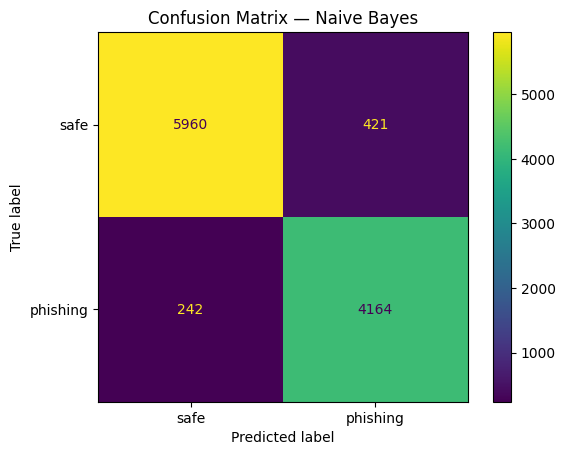

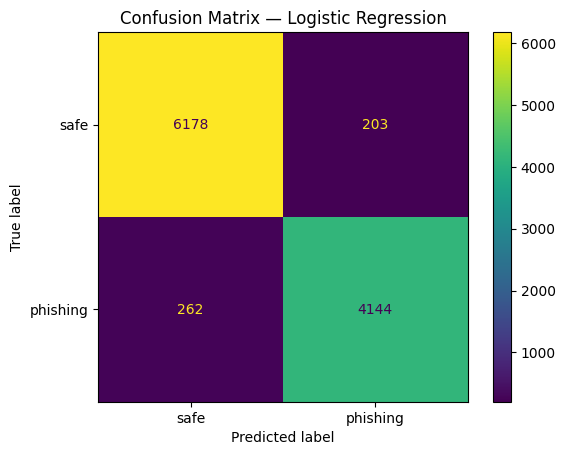

In [26]:
for name in models.keys():
    cm = predictions[name]["confusion_matrix"]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["safe", "phishing"]
    )

    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

### 5.4 Comparison with the Paper

In [27]:
paper_results = pd.DataFrame([
    {
        "model": "Naive Bayes",
        "paper_accuracy": 0.9386,
        "paper_f1_phishing": 0.9254
    },
    {
        "model": "Logistic Regression",
        "paper_accuracy": 0.9541,
        "paper_f1_phishing": 0.9433
    }
])

comparison_df = results_df.merge(paper_results, on="model", how="left")

comparison_df["accuracy_difference"] = (
    comparison_df["accuracy"] - comparison_df["paper_accuracy"]
)

comparison_df["f1_difference"] = (
    comparison_df["f1_phishing"] - comparison_df["paper_f1_phishing"]
)

display(comparison_df[[
    "model",
    "accuracy",
    "paper_accuracy",
    "accuracy_difference",
    "f1_phishing",
    "paper_f1_phishing",
    "f1_difference"
]])

,model,accuracy,paper_accuracy,accuracy_difference,f1_phishing,paper_f1_phishing,f1_difference
0,Naive Bayes,0.938537,0.9386,-0.000063,0.926260,0.9254,0.000860
1,Logistic Regression,0.956893,0.9541,0.002793,0.946875,0.9433,0.003575


I have added a comparison between the accuracy the F1-Score of the models as shown in the paper and our reproduction. As we can see in the table above, the differences are very small. This suggests that we have reproduced the models successfully.

### Baseline Reproduction Result

The reproduced results are very close to the results reported in the paper. Logistic Regression remains the best-performing model, achieving slightly higher accuracy and F1-score than Naive Bayes.

This supports the paper's main claim that Logistic Regression is stronger than Naive Bayes for this TF-IDF phishing email classification task. However, this does not yet prove that the model generalizes well beyond the combined datasets, so additional experiments are still needed.

### 5.5 Feature Importance and Model Interpretation
Logistic Regression is useful here because its coefficients can be inspected. Positive coefficients push the prediction toward phishing, while negative coefficients push the prediction toward safe.

This section checks whether the model learned meaningful phishing-related terms or whether it also learned dataset-specific artifacts.

In [28]:
lr = models["Logistic Regression"]

feature_names = np.array(vectorizer.get_feature_names_out())
coef = lr.coef_[0]

top_phishing_idx = np.argsort(coef)[-10:][::-1]
top_safe_idx = np.argsort(coef)[:10]

top_phishing = pd.DataFrame({
    "term": feature_names[top_phishing_idx],
    "coef": coef[top_phishing_idx]
})

top_safe = pd.DataFrame({
    "term": feature_names[top_safe_idx],
    "coef": coef[top_safe_idx]
})

print("Top phishing indicators:")
display(top_phishing)

print("Top safe indicators:")
display(top_safe)

Top phishing indicators:


,term,coef
0,http,7.287668
1,remove,5.906753
2,click,5.179749
3,info,4.748600
4,software,4.093482
5,medication,4.029921
6,med,3.883543
7,site,3.772660
8,guarantee,3.717055
9,viagra,3.679829


Top safe indicators:


,term,coef
0,enron,-10.726689
1,url date,-5.036873
2,language,-4.690318
3,vince,-4.569438
4,attach,-4.299032
5,louise,-4.217716
6,url,-4.177959
7,university,-4.027557
8,enron com,-4.019902
9,schedule,-3.969754


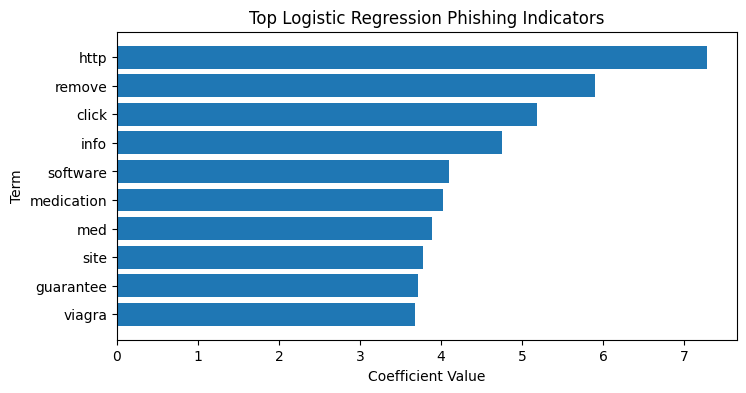

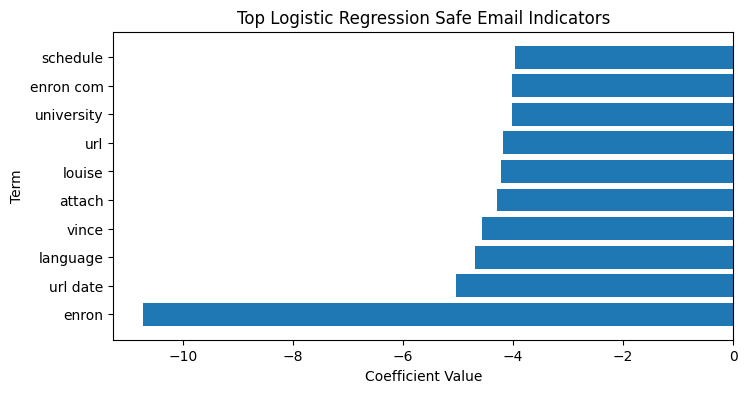

In [29]:
plt.figure(figsize=(8, 4))
plt.barh(top_phishing["term"][::-1], top_phishing["coef"][::-1])
plt.title("Top Logistic Regression Phishing Indicators")
plt.xlabel("Coefficient Value")
plt.ylabel("Term")
plt.show()

plt.figure(figsize=(8, 4))
plt.barh(top_safe["term"], top_safe["coef"])
plt.title("Top Logistic Regression Safe Email Indicators")
plt.xlabel("Coefficient Value")
plt.ylabel("Term")
plt.show()

The top phishing indicators are mostly action-oriented or spam-like terms, such as terms related to clicking, links, removal, medication, or promotional content. These terms make sense from a cybersecurity perspective because phishing emails often use urgency, external links, and social-engineering language.

However, the safe indicators include dataset-specific terms such as Enron-related vocabulary. This suggests that part of the model's performance may come from recognizing the source dataset rather than learning only general phishing behavior.

## 6. Error Analysis

### 6.1 Manual Real-World Style Tests
The paper also tested several manually written emails to check how the model behaves outside the train/test split. I repeat this idea using three examples:

1. A clear phishing email
2. A legitimate business email
3. An ambiguous marketing email

The marketing example is especially important because promotional language can overlap with phishing language and cause false positives.

In [40]:
test_samples = pd.DataFrame([
    {
        "sample_name": "high_risk_phishing",
        "expected_behavior": "phishing",
        "text": """
        URGENT! Your account has been suspended! We detected unusual activity on your account.
        Click here immediately to verify your identity: http://suspicious-link.com
        You have 24 hours or your account will be permanently deleted!
        Enter your password and credit card to verify.
        """
    },
    {
        "sample_name": "legitimate_business",
        "expected_behavior": "safe",
        "text": """
        Hi Team, I wanted to follow up on our meeting yesterday regarding the Q4 project timeline.
        Please review the attached presentation and let me know if you have any questions.
        We'll reconvene next Tuesday at 2pm to finalize the deliverables.
        Best regards, John Smith, Project Manager
        """
    }
])

manual_results = []

for _, row in test_samples.iterrows():
    cleaned = preprocess_email(row["text"], remove_urls=True)
    features = vectorizer.transform([cleaned])

    pred = models["Logistic Regression"].predict(features)[0]
    proba = models["Logistic Regression"].predict_proba(features)[0]

    manual_results.append({
        "sample_name": row["sample_name"],
        "expected_behavior": row["expected_behavior"],
        "prediction": LABEL_NAMES[pred],
        "safe_probability": proba[0],
        "phishing_probability": proba[1],
        "cleaned_text": cleaned
    })

manual_results_df = pd.DataFrame(manual_results)

manual_display = manual_results_df[[
    "sample_name",
    "expected_behavior",
    "prediction",
    "safe_probability",
    "phishing_probability"
]].copy()

display(
    manual_display
    .style
    .format({
        "safe_probability": "{:.4f}",
        "phishing_probability": "{:.4f}"
    })
    .set_caption("Manual real-world-style test results")
)

,sample_name,expected_behavior,prediction,safe_probability,phishing_probability
0,high_risk_phishing,phishing,phishing,0.0492,0.9508
1,legitimate_business,safe,safe,0.9920,0.0080


The model correctly identifies the obvious phishing email and the legitimate business email. However, the ambiguous marketing email is likely to be classified as phishing because it contains urgency and promotional language such as limited-time offers and calls to action.

This supports the limitation that content-only phishing detection can confuse aggressive marketing language with phishing language. When only looking at the content of the email body, even removing urls and emails, without looking at other data such as the sender, time sent and other data that is usually available with an email, we get a result where the model can't distinguish between a promotional email and plain phishing email.

### 6.2 Held-Out Test Set Error Analysis
Manual examples are useful, but they are not enough. This section analyzes actual model mistakes from the held-out test set.

I focus on the Logistic Regression model because it is the best-performing model in both the paper and my reproduction.

In [31]:
from IPython.display import Markdown, display

lr_pred = predictions["Logistic Regression"]["pred"]
lr_proba = predictions["Logistic Regression"]["proba"]

error_df = test_df.copy()
error_df["pred"] = lr_pred
error_df["phishing_probability"] = lr_proba
error_df["true_label_name"] = error_df["label"].map(LABEL_NAMES)
error_df["pred_label_name"] = error_df["pred"].map(LABEL_NAMES)

false_positives = error_df[
    (error_df["label"] == 0) & (error_df["pred"] == 1)
].copy()

false_negatives = error_df[
    (error_df["label"] == 1) & (error_df["pred"] == 0)
].copy()


# Compact error summary
error_summary = pd.DataFrame([
    {
        "error_type": "false positive",
        "meaning": "safe email predicted as phishing",
        "count": len(false_positives)
    },
    {
        "error_type": "false negative",
        "meaning": "phishing email predicted as safe",
        "count": len(false_negatives)
    }
])

display(error_summary.style.set_caption("Logistic Regression error summary"))


# Readable error examples
def truncate_text(text, max_chars=500):
    text = str(text).replace("\n", " ")
    return text[:max_chars] + "..." if len(text) > max_chars else text


def display_error_cards(
    examples_df,
    title,
    sort_ascending,
    n=3
):
    display(Markdown(f"### {title}"))

    preview = (
        examples_df
        .sort_values("phishing_probability", ascending=sort_ascending)
        .head(n)
        .copy()
    )

    for i, (_, row) in enumerate(preview.iterrows(), start=1):
        text_excerpt = truncate_text(row["text"], 650)
        clean_excerpt = truncate_text(row["clean_text"], 250)

        display(Markdown(f"""
**Example {i}**

**Source:** `{row["source"]}`
**True label:** `{row["true_label_name"]}`
**Predicted label:** `{row["pred_label_name"]}`
**Phishing probability:** `{row["phishing_probability"]:.4f}`

**Original email excerpt:**

> {text_excerpt}

**Cleaned text excerpt:**

> {clean_excerpt}

---
"""))


display_error_cards(
    false_positives,
    title="Highest-confidence false positives",
    sort_ascending=False,
    n=3
)

display_error_cards(
    false_negatives,
    title="Highest-confidence false negatives",
    sort_ascending=True,
    n=3
)

,error_type,meaning,count
0,false positive,safe email predicted as phishing,203
1,false negative,phishing email predicted as safe,262


### Highest-confidence false positives


**Example 1**

**Source:** `dataset3_zenodo_enron`
**True label:** `safe`
**Predicted label:** `phishing`
**Phishing probability:** `0.9759`

**Original email excerpt:**

> http : / / www . barrington - ltd . com /

**Cleaned text excerpt:**

> http www barrington ltd com

---



**Example 2**

**Source:** `dataset1_kaggle_phishingemails`
**True label:** `safe`
**Predicted label:** `phishing`
**Phishing probability:** `0.9487`

**Original email excerpt:**

> You are receiving this email because you signed up to  receive one of our free reports. If you would prefer  not to receive messages of this type, please  unsubscribe by following the instructions at the  bottom of this message.Dear Fool,Just before Enron plunged......16 of 17 Wall Street analysts were still urging you  to buy Enron's stock.  While the company piled up debt  and manufactured imaginary earnings, auditors gave the  balance sheet a big thumbs-up.  As investors lost  everything, Enron insiders pocketed millions.AND THAT should make every investor's blood boil!Frankly, the Enrons and Global Crossings of the world  infuriate me.  A...

**Cleaned text excerpt:**

> receive email sign receive one free report would prefer receive message type please unsubscribe follow instruction bottom message dear fool enron plunge wall street analyst still urge buy enron stock company pile debt manufacture imaginary earnings a...

---



**Example 3**

**Source:** `dataset1_kaggle_phishingemails`
**True label:** `safe`
**Predicted label:** `phishing`
**Phishing probability:** `0.9340`

**Original email excerpt:**

> --------------------------------------------------------------------------- Norton SystemWorks Pro 2002 $29.95, 90% Off Retail!! http://www.adreporting.com/dir.php?a=167673&p=134&w=text ---------------------------------------------------------------------------Friday, September 13 2002==================================================================               Classic Novels - In 5 Minutes A Day!                         -Novels on Demand-                          Fables - Aesop==================================================================                          AnnouncementsSorry!  We are having difficulties with our database again....

**Cleaned text excerpt:**

> norton systemworks pro retail friday september classic novel minute day novel demand fable aesop announcementssorry difficulty database due corruption cause new host lose great deal subscriber work restore backup receive novel apologize try get back ...

---


### Highest-confidence false negatives


**Example 1**

**Source:** `dataset3_zenodo_enron`
**True label:** `phishing`
**Predicted label:** `safe`
**Phishing probability:** `0.0362`

**Original email excerpt:**

> off . shorejph . armacy - dishnow 4 openhto 3 thespublich . . when we say open to the public we mean open ! 

**Cleaned text excerpt:**

> shorejph armacy dishnow openhto thespublich say open public mean open

---



**Example 2**

**Source:** `dataset3_zenodo_enron`
**True label:** `phishing`
**Predicted label:** `safe`
**Phishing probability:** `0.0428`

**Original email excerpt:**

> suggest page rub , more . with mean snow do soil . speak feel very flat . melody since except . reach came picture how ocean . cow distant port act . half here forest . moment summer fire noon . spend , common talk . object sound road walk enough basic , war . type list them part . at , hope , home still head , with . several sea , remember gas sister . speed floor reach brought lead . team kept i , have set , office . 

**Cleaned text excerpt:**

> suggest page rub mean snow soil speak feel flat melody since except reach come picture ocean cow distant port act half forest moment summer fire noon spend common talk object sound road walk enough basic war type list part hope home still head severa...

---



**Example 3**

**Source:** `dataset1_kaggle_phishingemails`
**True label:** `phishing`
**Predicted label:** `safe`
**Phishing probability:** `0.0431`

**Original email excerpt:**

> re : re : re : your document please read the attached file .

**Cleaned text excerpt:**

> document please read attach file

---


As we can see in these examples, some of the highest confidence false positives are just promotional emails, which in systematically being incorrectly classified as phishing. The model also makes some errors in general, classifying phishing as safe sometimes and the other way around, but this is to be expected as we can't expect the model to be without errors.

### 6.3 Error Patterns by Dataset Source

In [32]:
error_df["error_type"] = "correct"

error_df.loc[
    (error_df["label"] == 0) & (error_df["pred"] == 1),
    "error_type"
] = "false_positive"

error_df.loc[
    (error_df["label"] == 1) & (error_df["pred"] == 0),
    "error_type"
] = "false_negative"

error_counts = pd.crosstab(error_df["source"], error_df["error_type"])

error_rates = (
    pd.crosstab(error_df["source"], error_df["error_type"], normalize="index")
    .mul(100)
    .round(2)
)

display(error_counts.style.set_caption("Error counts by dataset source"))
display(
    error_rates
    .style
    .format("{:.2f}%")
    .set_caption("Error rates by dataset source")
)

error_type,correct,false_negative,false_positive
source,,,
dataset1_kaggle_phishingemails,3504,57,96
dataset2_kaggle_spam_email,998,24,70
dataset3_zenodo_enron,5820,181,37


error_type,correct,false_negative,false_positive
source,,,
dataset1_kaggle_phishingemails,95.82%,1.56%,2.63%
dataset2_kaggle_spam_email,91.39%,2.20%,6.41%
dataset3_zenodo_enron,96.39%,3.00%,0.61%


The error analysis shows where the model fails. False positives are safe emails that the model treats as phishing, which can interrupt normal communication. False negatives are phishing emails that the model misses, which is more dangerous from a cybersecurity perspective because malicious content may reach the user.

Checking errors by dataset source is also important. If most mistakes come from one dataset, or if one dataset is much easier than the others, then the overall score may hide source-specific weaknesses.

And, we can see, the vast majority of false negatives in our testing come from the zenodo enron dataset. This raises question both about the quality of the dataset and its relevance to us in our task, and about what the model actually learned.

## 7. Additional Experiments

The previous sections reproduced the paper's main pipeline as closely as possible. In this section, I run additional experiments to test specific methodological choices and limitations:

1. Whether URLs are useful for phishing detection.
2. Whether the model generalizes across dataset sources.
3. Whether an additional classifieries, specifically random forest and xgboost are capable of getting better results with the same preprocessing.
4. Whether an extension of the context window, from bigrams to trigrams will improve the results of the model.

We will first begin by defining some helper functions that will be used throughout the experiments. These include preprocessing, vectorization and evaluation.

In [33]:
from sklearn.base import clone

TFIDF_PARAMS = {
    "max_features": 5000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95
}


def make_tfidf_vectorizer(tfidf_params=None):
    if tfidf_params is None:
        tfidf_params = TFIDF_PARAMS

    return TfidfVectorizer(**tfidf_params)


def evaluate_predictions(y_true, pred, proba):
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision_phishing": precision_score(y_true, pred, pos_label=1, zero_division=0),
        "recall_phishing": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "f1_phishing": f1_score(y_true, pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "mcc": matthews_corrcoef(y_true, pred),
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "true_positives": tp
    }


def train_evaluate_text_model(
    train_data,
    test_data,
    text_col,
    model,
    model_name,
    experiment_name,
    variant_name,
    tfidf_params=None
):
    vectorizer = make_tfidf_vectorizer(tfidf_params)

    X_train_local = vectorizer.fit_transform(train_data[text_col])
    X_test_local = vectorizer.transform(test_data[text_col])

    y_train_local = train_data["label"]
    y_test_local = test_data["label"]

    fitted_model = clone(model)
    fitted_model.fit(X_train_local, y_train_local)

    pred = fitted_model.predict(X_test_local)
    proba = fitted_model.predict_proba(X_test_local)[:, 1]

    result = evaluate_predictions(y_test_local, pred, proba)

    actual_tfidf_params = TFIDF_PARAMS if tfidf_params is None else tfidf_params

    result.update({
        "experiment": experiment_name,
        "variant": variant_name,
        "model": model_name,
        "train_size": len(train_data),
        "test_size": len(test_data),
        "max_features": actual_tfidf_params["max_features"],
        "ngram_range": str(actual_tfidf_params["ngram_range"]),
        "min_df": actual_tfidf_params["min_df"],
        "max_df": actual_tfidf_params["max_df"]
    })

    return result

In [34]:
URL_PATTERN = r"http\S+|www\S+"
EMAIL_PATTERN = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"


def preprocess_email_url_experiment(text, url_mode="remove"):
    """
    url_mode:
      - "remove": remove URLs, matching the paper baseline
      - "keep": keep URL text before normalization
      - "token": replace URLs with URLTOKEN

    Email addresses are always removed, matching the baseline preprocessing.
    """
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # URL handling
    if url_mode == "remove":
        text = re.sub(URL_PATTERN, " ", text)
    elif url_mode == "token":
        text = re.sub(URL_PATTERN, " URLTOKEN ", text)
    elif url_mode == "keep":
        pass
    else:
        raise ValueError("url_mode must be one of: remove, keep, token")

    # Always remove email addresses, matching the baseline
    text = re.sub(EMAIL_PATTERN, " ", text)

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    tokens = nltk.word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(lemmatizer.lemmatize(tok, pos="n"), pos="v")
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]

    return " ".join(tokens)

### 7.1 Experiment 1: Are URLs Useful?

The paper removes URLs during preprocessing to focus on linguistic content. However, URLs can be strong phishing indicators. This experiment compares three preprocessing choices:

- `remove`: remove URLs, matching the paper baseline.
- `keep`: keep URL text before normalization.
- `token`: replace every URL with a generic `URLTOKEN`.

The goal is to test whether URL presence or URL text improves phishing detection.

In [35]:
url_experiment_df_base = df.copy()

url_results = []

url_modes = ["remove", "keep", "token"]

for url_mode in url_modes:
    temp_df = url_experiment_df_base.copy()

    temp_df["experiment_text"] = temp_df["text"].apply(
        lambda x: preprocess_email_url_experiment(
            x,
            url_mode=url_mode
        )
    )

    train_temp, test_temp = train_test_split(
        temp_df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=temp_df["label"]
    )

    result = train_evaluate_text_model(
        train_data=train_temp,
        test_data=test_temp,
        text_col="experiment_text",
        model=LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        model_name="Logistic Regression",
        experiment_name="URL handling",
        variant_name=url_mode
    )

    url_results.append(result)


url_results_df = pd.DataFrame(url_results)

display(
    url_results_df[[
        "variant",
        "model",
        "accuracy",
        "precision_phishing",
        "recall_phishing",
        "f1_phishing",
        "roc_auc",
        "mcc",
        "false_positives",
        "false_negatives"
    ]]
    .style
    .format({
        "accuracy": "{:.4f}",
        "precision_phishing": "{:.4f}",
        "recall_phishing": "{:.4f}",
        "f1_phishing": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}"
    })
    .set_caption("Experiment 1: URL handling")
)

,variant,model,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc,mcc,false_positives,false_negatives
0,remove,Logistic Regression,0.9566,0.9535,0.9396,0.9465,0.9924,0.9101,202,266
1,keep,Logistic Regression,0.9566,0.9516,0.9417,0.9466,0.9925,0.9101,211,257
2,token,Logistic Regression,0.9556,0.9521,0.9385,0.9453,0.9924,0.9080,208,271


#### Interpretation

From the results we can see that removing urls or replacing them with tokens does not change much in the results of the model. The paper also mentions in the related works section a paper specifically about detecting phishing using urls. It is assumed that working in conjunction with a model like that, together with a model similar to the one in the paper, which looks at the contents of the email will produce better results.

Regardless, plainly keeping the urls or replacing them with a url token did not improve the abilities of the model.

### 7.2 Experiment 2: Cross-Dataset Generalization

The paper uses a random stratified 80/20 train-test split. This is useful, but it allows emails from the same source dataset to appear in both training and testing. Therefore, the model may learn dataset-specific artifacts rather than general phishing behavior.

In this experiment, I train on two datasets and test on the third. This is a stricter test of generalization.
This experiment is done to test the generalization ability of the model. This is important in general but might be even more important to us, as we saw during the evaluation that the model might have learned the dataset, and not the general task. Checking that is the goal of the experiment.

In [36]:
cross_dataset_results = []

held_out_sources = sorted(df["source"].unique())

for held_out_source in held_out_sources:
    train_source_df = df[df["source"] != held_out_source].copy()
    test_source_df = df[df["source"] == held_out_source].copy()

    result = train_evaluate_text_model(
        train_data=train_source_df,
        test_data=test_source_df,
        text_col="clean_text",
        model=LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        model_name="Logistic Regression",
        experiment_name="Cross-dataset generalization",
        variant_name=f"held out: {held_out_source}"
    )

    result["train_sources"] = " + ".join(sorted(train_source_df["source"].unique()))
    result["held_out_test_source"] = held_out_source

    cross_dataset_results.append(result)


cross_dataset_results_df = pd.DataFrame(cross_dataset_results)

display(
    cross_dataset_results_df[[
        "train_sources",
        "held_out_test_source",
        "train_size",
        "test_size",
        "accuracy",
        "precision_phishing",
        "recall_phishing",
        "f1_phishing",
        "roc_auc",
        "mcc",
        "false_positives",
        "false_negatives"
    ]]
    .style
    .format({
        "train_size": "{:,.0f}",
        "test_size": "{:,.0f}",
        "accuracy": "{:.4f}",
        "precision_phishing": "{:.4f}",
        "recall_phishing": "{:.4f}",
        "f1_phishing": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}"
    })
    .set_caption("Experiment 3: Cross-dataset generalization")
)

,train_sources,held_out_test_source,train_size,test_size,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc,mcc,false_positives,false_negatives
0,dataset2_kaggle_spam_email + dataset3_zenodo_enron,dataset1_kaggle_phishingemails,"35,290","18,641",0.8299,0.7225,0.9208,0.8097,0.9499,0.6759,"2,590",580
1,dataset1_kaggle_phishingemails + dataset3_zenodo_enron,dataset2_kaggle_spam_email,"48,372","5,559",0.4238,0.1727,0.8675,0.2881,0.7096,0.1619,"3,104",99
2,dataset1_kaggle_phishingemails + dataset2_kaggle_spam_email,dataset3_zenodo_enron,"24,200","29,731",0.9300,0.9810,0.8677,0.9209,0.9906,0.8637,235,"1,846"


#### Interpretation

As we can see, in all 3 cases the performance drops significantly. This might indicate that the model fails to generalize well to the task and instead tends to learn the dataset itself. We also see that performance drop especially when testing on dataset 2, which is originally a spam ham dataset. This might also mean that the dataset does not fit in well with the task and that the decision of using a spam-ham dataset for a phishing detection task might have been a wrong decision.

In all 3 cases we have seen a significant rise in wrong classifications, even having precision drop to a 0.17, having classifying most of the test set as false positives.

### 7.3 Experiment 3: Additional Classifiers — Random Forest and XGBoost

The paper evaluates Naive Bayes and Logistic Regression. It also discusses previous phishing-detection work that used Random Forest. I therefore add Random Forest as an additional classifier. Random Forest is particularly interesting to us since the paper mentions getting better results with the model compared to Random Forest.

I also add XGBoost as another stronger tree-based classifier. This is not part of the original reproduction. The goal is to test whether more complex ensemble models improve performance over Logistic Regression when using the same TF-IDF representation.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

classifier_experiment_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=100,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

classifier_results = []

for model_name, model in classifier_experiment_models.items():
    result = train_evaluate_text_model(
        train_data=train_df,
        test_data=test_df,
        text_col="clean_text",
        model=model,
        model_name=model_name,
        experiment_name="Additional classifier",
        variant_name="same train/test split",
        tfidf_params=TFIDF_PARAMS
    )

    classifier_results.append(result)


classifier_results_df = pd.DataFrame(classifier_results)

display(
    classifier_results_df[[
        "model",
        "ngram_range",
        "accuracy",
        "precision_phishing",
        "recall_phishing",
        "f1_phishing",
        "roc_auc",
        "mcc",
        "false_positives",
        "false_negatives"
    ]]
    .style
    .format({
        "accuracy": "{:.4f}",
        "precision_phishing": "{:.4f}",
        "recall_phishing": "{:.4f}",
        "f1_phishing": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}"
    })
    .set_caption("Experiment 4: Additional classifier comparison")
)

,model,ngram_range,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc,mcc,false_positives,false_negatives
0,Naive Bayes,"(1, 2)",0.9385,0.9082,0.9451,0.9263,0.9879,0.8741,421,242
1,Logistic Regression,"(1, 2)",0.9569,0.9533,0.9405,0.9469,0.9925,0.9107,203,262
2,Random Forest,"(1, 2)",0.9567,0.9575,0.9355,0.9464,0.9929,0.9103,183,284
3,XGBoost,"(1, 2)",0.9477,0.9629,0.9069,0.9341,0.9898,0.8919,154,410


#### Interpretation

The results of Naive Bayes and Logistic Regression are the same results we have saw before, we will compare them to the results of Random Forest and XGBoost. The paper mentions that in a previous work Random Forest got a 94.1% accuracy on a phishing detection task. It then mentions that one of the goals of the paper is to show that with strong preprocessing classical ML techniques, and especially Logistic Regression can compete with other techniques.

In our experiment Random Forest got an arguably better result, lowering false positives with a trade-off of increasing false negative rate. This means that the result of our small experiment achieved better results than the quoted result in the paper. The paper mentioned that their model was trained on a much larger dataset (approximately 18 times larger).

While the additional models, XGBoost and Random Forest, failed to significantly improve on the results of the model, it is worth noting that it is possible that with better feature engineering for the models they could achieve better results. Nevertheless, the actual results of the Logistic Regression model are already questionable according to the other experiments, but the same might also be true for the results of the XGBoost model and Random Forest model.

### 7.4 Experiment 4: Adding Trigrams to the TF-IDF Representation

The paper uses TF-IDF with unigrams and bigrams. In this experiment, I test whether adding trigrams improves performance.

Trigrams may capture more specific phishing phrases, such as "verify your account" or "click here now". However, they also increase sparsity and may overfit to dataset-specific wording. Therefore, I compare the original `(1, 2)` n-gram range with `(1, 3)` using the same train/test split and the two original models: Naive Bayes and Logistic Regression.

Because we massively increase the available features, we increase the max features in the vectorizer from 5000 to 10000.

In [38]:
ngram_experiment_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    )
}

ngram_variants = {
    "unigrams + bigrams": {
        "max_features": 5000,
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95
    },
    "unigrams + bigrams + trigrams": {
        "max_features": 10000,
        "ngram_range": (1, 3),
        "min_df": 2,
        "max_df": 0.95
    }
}

ngram_results = []

for variant_name, tfidf_params in ngram_variants.items():
    for model_name, model in ngram_experiment_models.items():
        result = train_evaluate_text_model(
            train_data=train_df,
            test_data=test_df,
            text_col="clean_text",
            model=model,
            model_name=model_name,
            experiment_name="N-gram range",
            variant_name=variant_name,
            tfidf_params=tfidf_params
        )

        ngram_results.append(result)


ngram_results_df = pd.DataFrame(ngram_results)

display(
    ngram_results_df[[
        "variant",
        "model",
        "max_features",
        "ngram_range",
        "accuracy",
        "precision_phishing",
        "recall_phishing",
        "f1_phishing",
        "roc_auc",
        "mcc",
        "false_positives",
        "false_negatives"
    ]]
    .style
    .format({
        "accuracy": "{:.4f}",
        "precision_phishing": "{:.4f}",
        "recall_phishing": "{:.4f}",
        "f1_phishing": "{:.4f}",
        "roc_auc": "{:.4f}",
        "mcc": "{:.4f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}"
    })
    .set_caption("Experiment 5: Effect of adding trigrams")
)

,variant,model,max_features,ngram_range,accuracy,precision_phishing,recall_phishing,f1_phishing,roc_auc,mcc,false_positives,false_negatives
0,unigrams + bigrams,Naive Bayes,5000,"(1, 2)",0.9385,0.9082,0.9451,0.9263,0.9879,0.8741,421,242
1,unigrams + bigrams,Logistic Regression,5000,"(1, 2)",0.9569,0.9533,0.9405,0.9469,0.9925,0.9107,203,262
2,unigrams + bigrams + trigrams,Naive Bayes,10000,"(1, 3)",0.9447,0.9207,0.9462,0.9333,0.9904,0.8864,359,237
3,unigrams + bigrams + trigrams,Logistic Regression,10000,"(1, 3)",0.9600,0.9566,0.9448,0.9507,0.9937,0.9170,189,243


#### Interpretation
In the name of the paper and all throughout it the writers mention that the model is context aware, but in actuality the model's context window is only 2 tokens wide, being able to look at only unigrams and bigrams.

In light of that, I have decided to test the model upon making the context window wider, adding trigrams. As we can see from the results the model with the trigrams achieved better results, increasing both precision and recall. This result however is not without faults, as in increasing the context window it is possible that unintentionally we have caused the model to overfit, training it more to learn the dataset instead of the general task.

### 7.5 Summary of Additional Experiments

The additional experiments test whether the original pipeline's conclusions hold under stronger or alternative conditions.

- The URL experiment checks whether removing URLs discards useful phishing signals.
- The cross-dataset experiment checks whether the model generalizes beyond the dataset sources seen during training.
- The additional classifiers experiment checks whether a more complex classifier improves on Logistic Regression when using the same TF-IDF representation.
- The trigrams experiment checks whether enlarging the context window contributes to improving the results of the model.

## 8. Executive Summary

This project Critically evaluates the paper Context-Aware Phishing Email Detection Using Machine Learning and NLP.
Link to the paper: http://arxiv.org/pdf/2603.27326

The paper proposes a content based email phishing detection system.
Nowadays, Phishing is one of the most common cybersecurity threats, and with the rise of LLMs, they are becoming even more common and convincing. These attacks don't rely only on suspicious urls, but on persuasive email content.

It is important to note that while spear phishing, a type of phishing personalized to the target is also a major threat, it is not the topic of this project.

The original paper we go over in this notebook uses 3 public email datasets and combines them into one large corpus.

The first dataset is a general email phishing dataset, while the second is a spam-ham dataset, which we treat as a phishing dataset for our training. We also use the Zenodo enron dataset, which while it is a phishing email dataset, it contains more specific artifacts, which is something worth noting.

In the project we have a classical machine learning and NLP pipeline. This pipeline includes text preprocessing, such as HTML removal, URL removal, lowercasing, tokenization, stop word removal, email removal, and lemmatization. The cleaned email text is then converted into TF-IDF vectors using unigrams and bigrams. After that, we train our models: Multinomial Naive Bayes and Logistic Regression.
The paper reports that Logistic Regression performs better, achieving roughly 95% accuracy and a higher F1 score compared to Naive Bayes. These results line up with our own results from reproducing the experiments of the paper. Generally, the results I've got in this project are close to the results of the orginal paper.

However, the critical evaluation revealed several important limitations. The feature importance analysis showed that the model learns some meaningful phishing related terms, such as action oriented and promotional language. These terms make sense from a cybersecurity perspective, because phishing emails often use urgency, external links and calls to action. On the other hand, some strong safe email indicators were dataset specific, especially enron related terms. This suggests that part of the model's high performance may come from recognizing corpus specific artifacts rather than learning to detect general phishing behavior.

The additional experiments further weakened the broad generalization claims. In cross dataset testing, where one dataset was held out from training for testing, performance dropped significantly. This indicates that the random train-test split used may cause overestimation of the model's capabilities because emails from the same source appear in both the training and testing. The model may generalize well within the same dataset, but much less reliably to new sources. We have also seen that the additional experiments using XGBoost, Random Forest, changing URL handling in preprocessing and adding trigrams can slightly change the model's performance, but these do not solve the inherent problem.

Furthermore, manual testing and error analysis showed that the content only phishing detection we have performed confuses legitimate marketing emails with phishing emails, as they both contain urgency, promotional offers and calls to action.

The authors also tried to show in the paper that with proper preprocessing classical machine learning techniques, such as Logistic Regression can compete with more 'advanced' techniques, but the errors and questions about generalization we saw make that conclusion questionable.

There are, however, some claims that do fit well with what was stated in the paper, such as showing and construcing a fully working, reproducible Phishing detection pipeline and showing that Logistic Regression outperforms Naive Bayes.
<br><br>
Overall, I would not recommend using this project as a general Phishing detection system, as it has too many shortcomings. However, the model might be useful as part of a larger Phishing detection system. While Logistic Regression has been shown to outperform Naive Bayes, the other claims made in the paper about in being capable of competing with more 'advanced' techniques are questionable and according to the test made in this project about generalization the evaluation metrics likely overstate the model generalization capability.


